<a href="https://colab.research.google.com/github/Bhavya-Chellapandian/Social-Media-Engagement-Analytics-Using-Python/blob/main/Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Social Media Engagement Analytics Using Python




In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

1.Data Import & Setup

In [ ]:
from google.colab import files
uploaded = files.upload()
file_path = "social_media_engagement_5000.csv"
df = pd.read_csv(file_path)
df.head()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.dtypes)


Rows: 5000
Columns: 19
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object


In [ ]:

# Convert date column to datetime
df["posted_at"] = pd.to_datetime(df["posted_at"], dayfirst=True)


2.Data Cleaning & Transformation

In [ ]:
# Missing-value
missing_before = df.isna().sum()
print(missing_before)


user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
# Duplicate and removal
duplicates = df.duplicated().sum()
print("Duplicate rows: ", duplicates)


Duplicate rows:  0


In [ ]:
# Standardize text/category fields
text_cols = ["gender", "country", "post_type", "post_category", "device_type", "sentiment"]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip().str.lower()

# Standardize boolean field
df["is_verified"] = df["is_verified"].astype(bool)

# Numeric columns
numeric_cols = ["age", "likes", "comments", "shares", "watch_time_sec",
    "impression_count", "follower_count", "engagement_rate"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

# Convert impossible negative values to missing
non_negative_cols = ["age", "likes", "comments", "shares", "watch_time_sec",
    "impression_count", "follower_count", "engagement_rate"]
for col in non_negative_cols:
    df.loc[df[col] < 0, col] = np.nan

# Treat ages outside a reasonable social-media user range as missing
df.loc[(df["age"] < 13) | (df["age"] > 100), "age"] = np.nan


In [ ]:
# Handle missing values
# Numeric values
for col in ["age", "likes", "comments", "shares"]:
    df[col] = df[col].fillna(df[col].median())
# Categorical values
for col in ["gender", "sentiment"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Clean sentiment labels and create hashtag count
valid_sentiments = {"positive", "neutral", "negative"}
df["sentiment"] = df["sentiment"].where(df["sentiment"].isin(valid_sentiments), df["sentiment"].mode()[0])

def count_hashtags(value):
    if pd.isna(value) or str(value).strip() == "":
        return 0
    return len([x for x in str(value).split() if x.startswith("#")])

df["hashtag_count"] = df["hashtags"].apply(count_hashtags)

# Create engagement score
df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

# Date features
df["year"] = df["posted_at"].dt.year
df["month"] = df["posted_at"].dt.month
df["month_name"] = df["posted_at"].dt.month_name()
df["day_of_week"] = df["posted_at"].dt.day_name()

display(df[["hashtags", "hashtag_count", "likes", "comments", "shares", "engagement_score"]].head())


,hashtags,hashtag_count,likes,comments,shares,engagement_score
0,#foodie #travel #love,3,7011.0,354.0,1157.0,8522.0
1,#fitness,1,11750.0,2606.0,1807.0,16163.0
2,#foodie,1,4862.0,344.0,955.0,6161.0
3,#music #foodie #fun,3,5350.0,1083.0,1049.0,7482.0
4,#travel,1,12682.0,2735.0,1300.0,16717.0


3.Data Exploration Using Pandas

In [ ]:
# head, tail, shape, columns
display(df.head())
display(df.tail())
print(df.shape)
print(df.columns.tolist())


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,year,month,month_name,day_of_week
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,...,mobile,negative,#foodie #travel #love,0.190862,3,8522.0,2022,12,December,Saturday
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,...,mobile,negative,#fitness,0.201493,1,16163.0,2023,6,June,Friday
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,...,tablet,positive,#foodie,0.137345,1,6161.0,2023,5,May,Sunday
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,...,mobile,negative,#music #foodie #fun,0.106195,3,7482.0,2023,2,February,Sunday
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,...,mobile,negative,#travel,2.777372,1,16717.0,2023,5,May,Tuesday


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,year,month,month_name,day_of_week
4995,59500,44.0,male,australia,441541,video,education,16210.0,2013.0,1837.0,...,mobile,positive,#travel #fun,0.466761,2,20060.0,2022,6,June,Saturday
4996,22100,38.0,other,uae,677076,reel,education,16924.0,2734.0,1583.0,...,desktop,negative,#foodie #reels,0.621155,2,21241.0,2022,11,November,Friday
4997,67021,63.0,female,usa,273595,text,travel,13487.0,1497.0,167.0,...,desktop,positive,#lifestyle #tech,0.679688,2,15151.0,2023,4,April,Thursday
4998,29800,13.0,female,germany,785644,video,fitness,16894.0,1289.0,1713.0,...,tablet,positive,#reels #love #fitness,0.223518,3,19896.0,2022,5,May,Monday
4999,73400,54.0,other,japan,712252,text,travel,14830.0,503.0,1798.0,...,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3,17131.0,2023,3,March,Saturday


(5000, 25)
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count', 'engagement_score', 'year', 'month', 'month_name', 'day_of_week']


In [ ]:
# info and dtypes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   string        
 3   country           5000 non-null   string        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   string        
 6   post_category     5000 non-null   string        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   float64       
 11  impression_count  5000 non-null   float64       
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   float64       
 14  is_verified       5000 n

In [ ]:
# Summary statistics
display(df.describe(include="all").T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,5000.0,NaN,NaN,NaN,54561.8908,10055.0,32309.5,54374.5,77180.5,99963.0,26090.370121
age,5000.0,NaN,NaN,NaN,38.4404,13.0,26.0,38.0,51.0,64.0,14.687151
gender,5000,3,male,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,10,india,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,5000.0,NaN,NaN,NaN,548042.909,100068.0,322543.5,548077.5,771574.5,999455.0,260646.957267
post_type,5000,4,reel,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_category,5000,8,fitness,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
likes,5000.0,NaN,NaN,NaN,10106.9974,10.0,5235.0,10105.5,14959.0,19998.0,5702.293017
comments,5000.0,NaN,NaN,NaN,1502.0398,0.0,792.0,1497.0,2235.25,2999.0,856.393312
shares,5000.0,NaN,NaN,NaN,1002.9106,0.0,511.0,1012.0,1483.0,1999.0,570.8552


In [ ]:
# Categorical distributions
categorical_cols = ["gender", "country", "post_type", "post_category", "device_type", "sentiment"]

for col in categorical_cols:
    print(col)
    print("Unique:", df[col].unique())
    print("Nunique:", df[col].nunique())
    display(df[col].value_counts().to_frame("count"))


gender
Unique: <StringArray>
['female', 'male', 'other']
Length: 3, dtype: string
Nunique: 3


,count
gender,
male,1849
other,1581
female,1570


country
Unique: <StringArray>
[   'brazil',        'uk',    'france',    'canada',     'japan', 'australia',
     'india',       'uae',   'germany',       'usa']
Length: 10, dtype: string
Nunique: 10


,count
country,
india,535
canada,513
brazil,504
uae,503
usa,501
france,496
uk,493
australia,493
germany,490


post_type
Unique: <StringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: string
Nunique: 4


...

,count
post_category,
fitness,675
tech,665
music,635
education,631
lifestyle,607
travel,600
fashion,594
food,593


device_type
Unique: <StringArray>
['mobile', 'tablet', 'desktop']
Length: 3, dtype: string
Nunique: 3


,count
device_type,
mobile,1684
tablet,1658
desktop,1658


sentiment
Unique: <StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: string
Nunique: 3


,count
sentiment,
positive,2513
neutral,1527
negative,960


In [ ]:
# NumPy example: numeric array summary
numeric_array = df[["likes", "comments", "shares", "watch_time_sec", "followers" if "followers" in df.columns else "follower_count"]].to_numpy()

print("NumPy array shape:", numeric_array.shape)
print("Overall numeric mean:", np.nanmean(numeric_array))
print("Overall numeric median:", np.nanmedian(numeric_array))


NumPy array shape: (5000, 5)
Overall numeric mean: 82064.93516
Overall numeric median: 2972.0


In [ ]:
# Correlation matrix for numeric fields
corr_cols = ["age", "likes", "comments", "shares", "watch_time_sec",
    "impression_count", "follower_count", "engagement_rate",
    "hashtag_count", "engagement_score"]
corr_matrix = df[corr_cols].corr()
display(corr_matrix)


,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count,engagement_score
age,1.000000,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173,-0.035531
likes,-0.036322,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190,0.983942
comments,-0.007284,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230,0.130552
shares,0.013871,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379,0.104285
watch_time_sec,0.005542,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301,0.007616
impression_count,0.013322,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714,0.005937
follower_count,-0.024894,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802,-0.025467
engagement_rate,0.008039,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319,0.094382
hashtag_count,0.007173,-0.002190,-0.015230,0.013379,-0.023301,-0.002714,0.008802,0.005319,1.000000,-0.003094
engagement_score,-0.035531,0.983942,0.130552,0.104285,0.007616,0.005937,-0.025467,0.094382,-0.003094,1.000000


In [ ]:
# Groupby summaries
avg_likes_post_type = df.groupby("post_type")["likes"].mean().sort_values(ascending=False)
avg_impressions_country = df.groupby("country")["impression_count"].mean().sort_values(ascending=False)
display(avg_likes_post_type)
display(avg_impressions_country)


,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


,impression_count
country,
india,52462.386916
france,51727.673387
usa,51263.872255
uk,51119.393509
japan,49616.135593
brazil,49193.174603
uae,48928.413519
canada,48703.150097
germany,48605.406122


4.Data Wrangling & Feature Engineering

In [ ]:
# Create an additional engagement-rate check from available interaction metrics
df["calculated_engagement_rate_pct"] = (df["engagement_score"] / df["impression_count"]) * 100

# Engagement rate by groups
group_post_type = df.groupby("post_type").agg(posts=("post_id", "count"),
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_engagement_score=("engagement_score", "mean"),
    avg_likes=("likes", "mean"))
group_category = df.groupby("post_category").agg(posts=("post_id", "count"),
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_engagement_score=("engagement_score", "mean"))
group_sentiment = df.groupby("sentiment").agg(posts=("post_id", "count"),
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_engagement_score=("engagement_score", "mean"),
    avg_likes=("likes", "mean"))
display(group_post_type)
display(group_category)
display(group_sentiment)


,posts,avg_engagement_rate,avg_engagement_score,avg_likes
post_type,,,,
image,1247,0.895646,12649.390537,10104.865277
reel,1283,0.783047,12524.031567,10037.802416
text,1245,1.064549,12613.243775,10100.148193
video,1225,1.122365,12664.594286,10188.600000


,posts,avg_engagement_rate,avg_engagement_score
post_category,,,
education,631,0.844222,12578.270206
fashion,594,0.807109,12356.420875
fitness,675,0.865628,12457.791852
food,593,1.358628,12739.200675
lifestyle,607,1.091019,12639.539539
music,635,0.888803,12788.549606
tech,665,1.160475,12686.490226
travel,600,0.702223,12650.559167


,posts,avg_engagement_rate,avg_engagement_score,avg_likes
sentiment,,,,
negative,960,1.038486,12731.498958,10208.096875
neutral,1527,0.991170,12448.163720,9923.194499
positive,2513,0.919744,12665.799443,10180.062077


In [ ]:
# Country and sentiment summaries
country_summary = df.groupby("country").agg(posts=("post_id", "count"),
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_impressions=("impression_count", "mean"),
    avg_likes=("likes", "mean"))
display(country_summary)


,posts,avg_engagement_rate,avg_impressions,avg_likes
country,,,,
australia,493,1.324339,48346.383367,10294.124746
brazil,504,1.540704,49193.174603,9886.689484
canada,513,0.916659,48703.150097,10063.066277
france,496,1.146402,51727.673387,10372.876008
germany,490,0.759000,48605.406122,10130.458163
india,535,0.655005,52462.386916,9962.468224
japan,472,0.769623,49616.135593,10088.862288
uae,503,1.112352,48928.413519,10227.487078
uk,493,0.850966,51119.393509,9935.650101


In [ ]:
# concat/merge workflow using aggregated DataFrames
post_summary = df.groupby("post_type").agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"))
category_summary = df.groupby("post_category").agg(
    avg_shares=("shares", "mean"),
    avg_engagement=("engagement_rate", "mean"))
combined_summary = pd.concat(
    [post_summary.rename(columns={"post_type": "dimension"}),
     category_summary.rename(columns={"post_category": "dimension"})],)
display(combined_summary)


,avg_likes,avg_comments,avg_shares,avg_engagement
image,10104.865277,1525.235766,NaN,NaN
reel,10037.802416,1504.187062,NaN,NaN
text,10100.148193,1499.106024,NaN,NaN
video,10188.600000,1479.160000,NaN,NaN
education,NaN,NaN,996.445325,0.844222
fashion,NaN,NaN,982.523569,0.807109
fitness,NaN,NaN,1042.047407,0.865628
food,NaN,NaN,1002.801012,1.358628
lifestyle,NaN,NaN,991.140033,1.091019
music,NaN,NaN,1024.089764,0.888803


5.Statistical Analysis

In [ ]:
# Descriptive statistics for required metrics
stats_cols = ["likes", "comments", "shares",
    "watch_time_sec", "engagement_rate", "follower_count"]
stat_rows = []
for col in stats_cols:
    s = df[col].dropna()
    mode_values = s.mode()
    stat_rows.append({
        "Metric": col,
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode": mode_values.iloc[0] if not mode_values.empty else np.nan,
        "Std Dev": s.std(),
        "Variance": s.var(),
        "P25": s.quantile(0.25),
        "P50": s.quantile(0.50),
        "P75": s.quantile(0.75),
        "P90": s.quantile(0.90)})
stats_table = pd.DataFrame(stat_rows)
display(stats_table)


,Metric,Mean,Median,Mode,Std Dev,Variance,P25,P50,P75,P90,P95
0,likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000,18016.3000,19097.050000
1,comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000,2695.1000,2861.000000
2,shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000,1795.1000,1901.050000
3,watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000,7212.1000,7577.050000
4,engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794,1.2012,2.328526
5,follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000,717755.9000,760174.350000


In [ ]:
# skewness and kurtosis
distribution_stats = df[stats_cols].agg(["skew", "kurtosis"]).T
display(distribution_stats)


,skew,kurtosis
likes,-0.006894,-1.149992
comments,0.003802,-1.144375
shares,-0.014654,-1.146857
watch_time_sec,-0.018196,-1.195652
engagement_rate,18.781271,482.991739
follower_count,0.041118,-1.189474


6.Data Visualization — Matplotlib

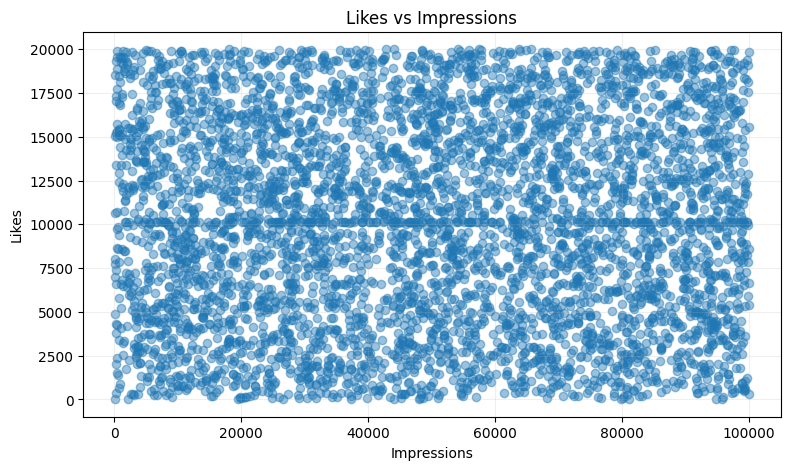

In [ ]:
# 1.Scatter: Likes vs Impressions
plt.figure(figsize=(9, 5))
plt.scatter(df["impression_count"], df["likes"], alpha=0.45)
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Likes vs Impressions")
plt.grid(alpha=0.2)
plt.show()


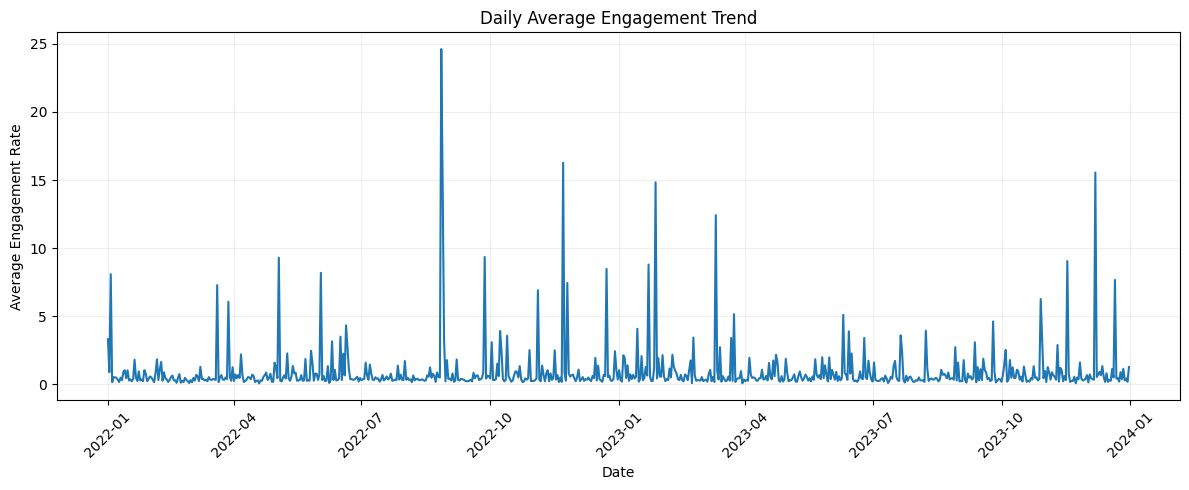

In [ ]:
# 2.Line: Daily engagement trend
daily_engagement = df.groupby("posted_at")["engagement_rate"].mean().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel("Date")
plt.ylabel("Average Engagement Rate")
plt.title("Daily Average Engagement Trend")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


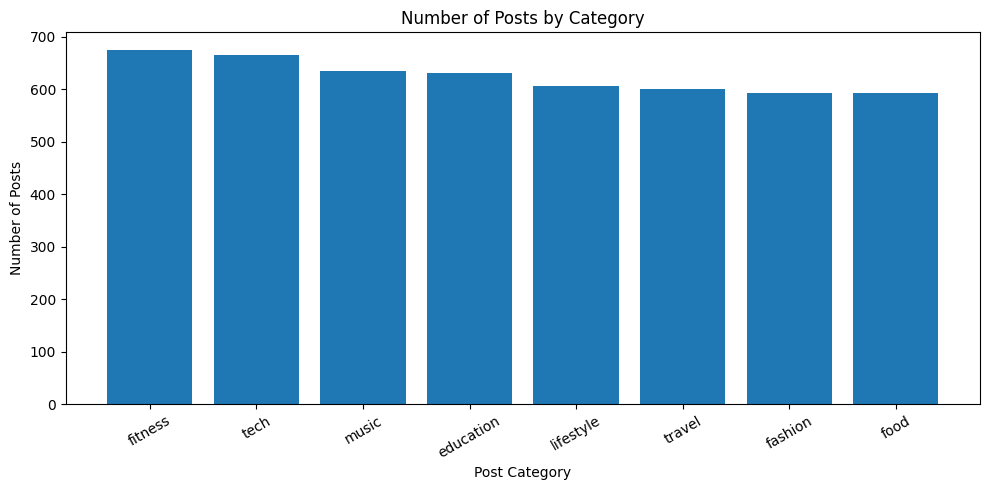

In [ ]:
# 3.Bar: Posts by category
category_counts = df["post_category"].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.title("Number of Posts by Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


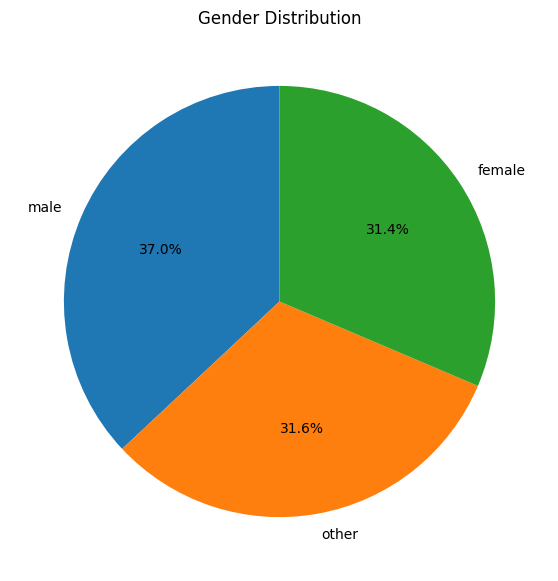

In [ ]:
# 4.Pie: Gender distribution
gender_counts = df["gender"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution")
plt.show()


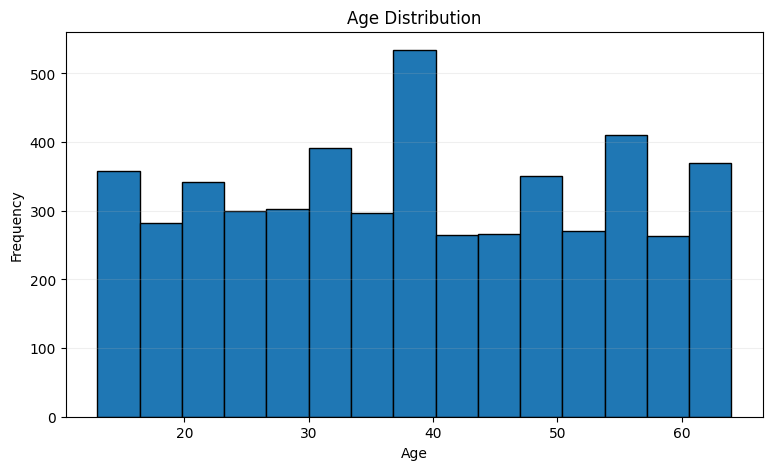

In [ ]:
# 5.Histogram: Age
plt.figure(figsize=(9, 5))
plt.hist(df["age"], bins=15, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.grid(axis="y", alpha=0.2)
plt.show()


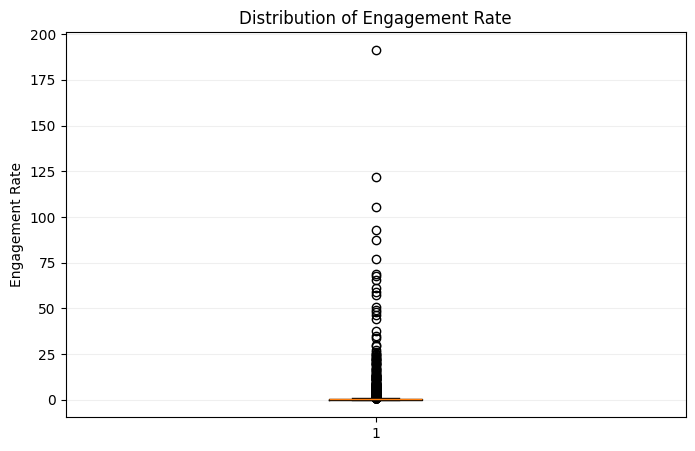

In [ ]:
#6.Box plot: Engagement rate
plt.figure(figsize=(8, 5))
plt.boxplot(df["engagement_rate"].dropna(), vert=True)
plt.ylabel("Engagement Rate")
plt.title("Distribution of Engagement Rate")
plt.grid(axis="y", alpha=0.2)
plt.show()


7.Data Visualization — Seaborn

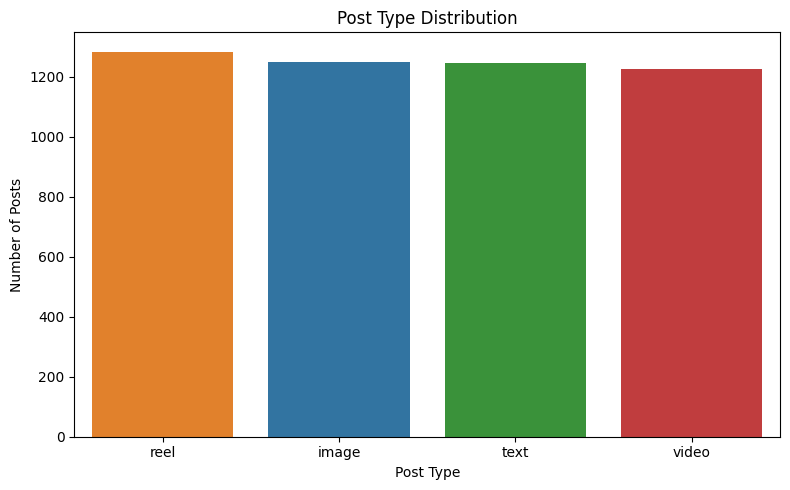

In [ ]:
#7.Count plot: Post type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="post_type", hue="post_type", order=df["post_type"].value_counts().index, legend=False)
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.title("Post Type Distribution")
plt.tight_layout()
plt.show()


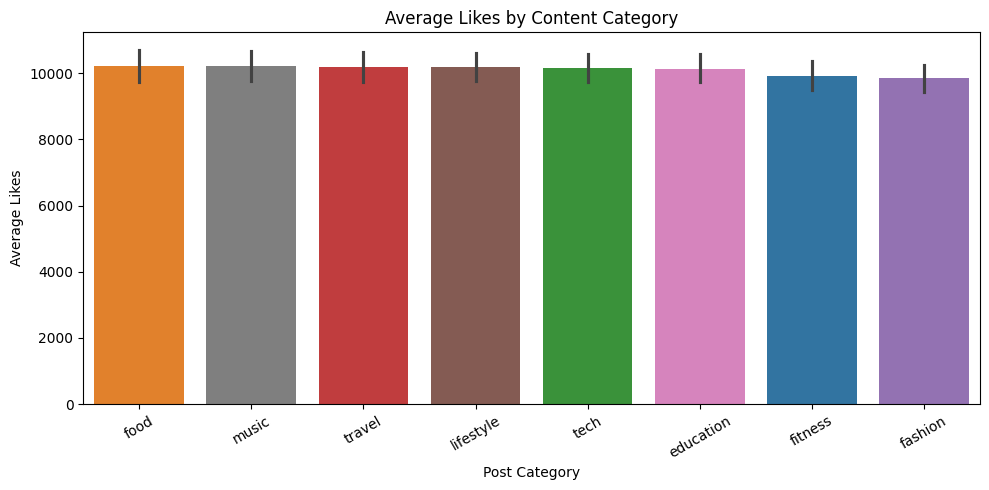

In [ ]:
#8.Bar plot: Average likes by category
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    hue="post_category",
    legend=False,
    estimator=np.mean,
    order=df.groupby("post_category")["likes"].mean().sort_values(ascending=False).index)
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.title("Average Likes by Content Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


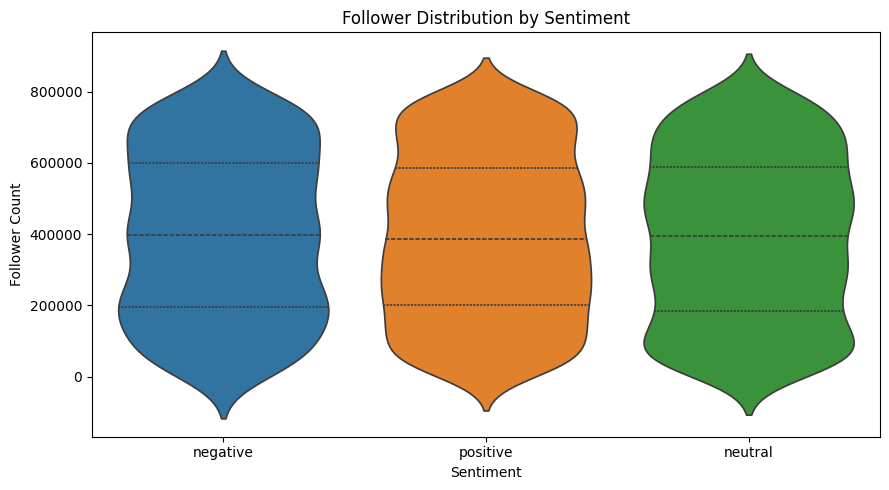

In [ ]:
#9.Violin plot: Followers vs sentiment
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="sentiment", y="follower_count", hue="sentiment", inner="quartile", legend=False)
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.title("Follower Distribution by Sentiment")
plt.tight_layout()
plt.show()


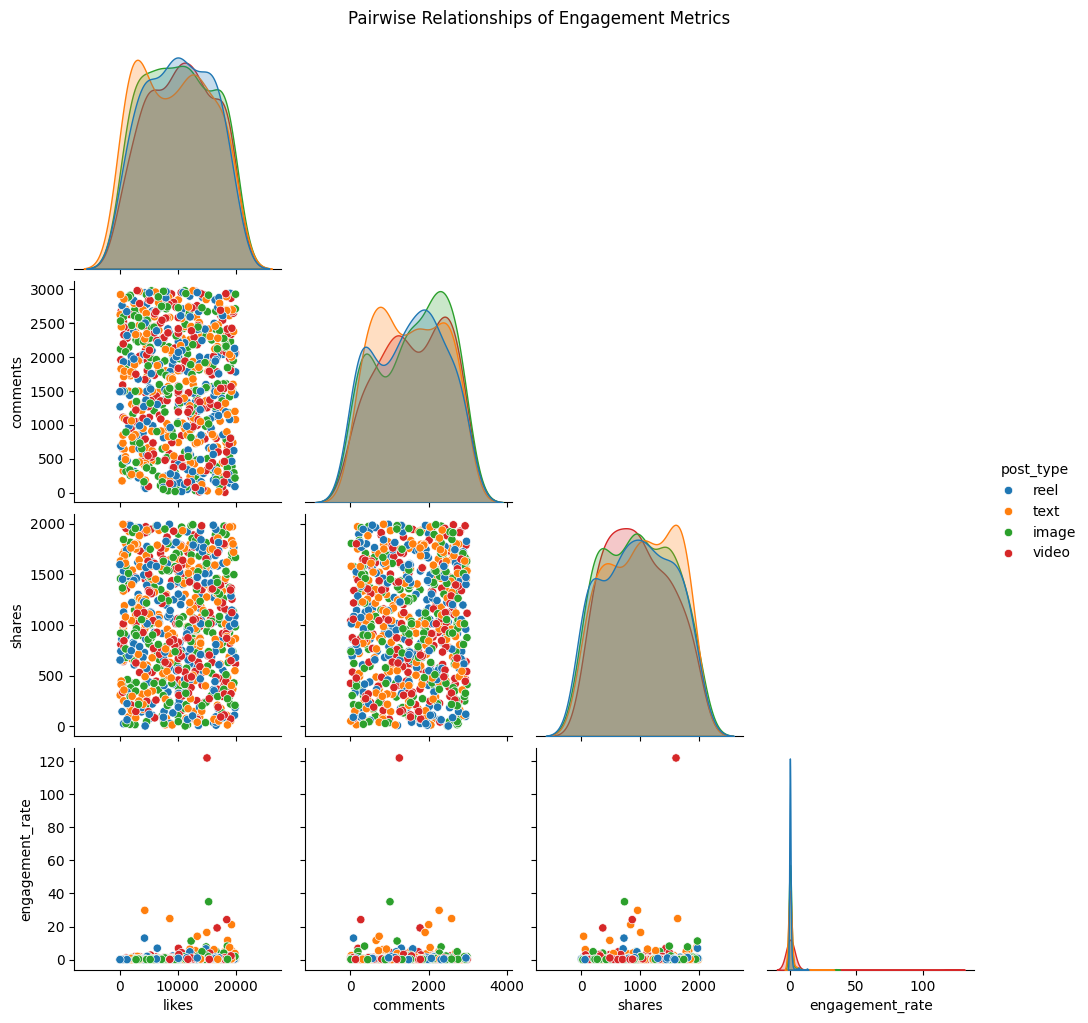

In [ ]:
# 10.Pair plot: selected numeric features
pair_cols = ["likes", "comments", "shares", "engagement_rate"]
pair_sample = df[pair_cols].sample(min(800, len(df)), random_state=42)

pair_sample_plot = df.loc[pair_sample.index, pair_cols + ["post_type"]]
sns.pairplot(pair_sample_plot, corner=True, hue="post_type")
plt.suptitle("Pairwise Relationships of Engagement Metrics", y=1.02)
plt.show()


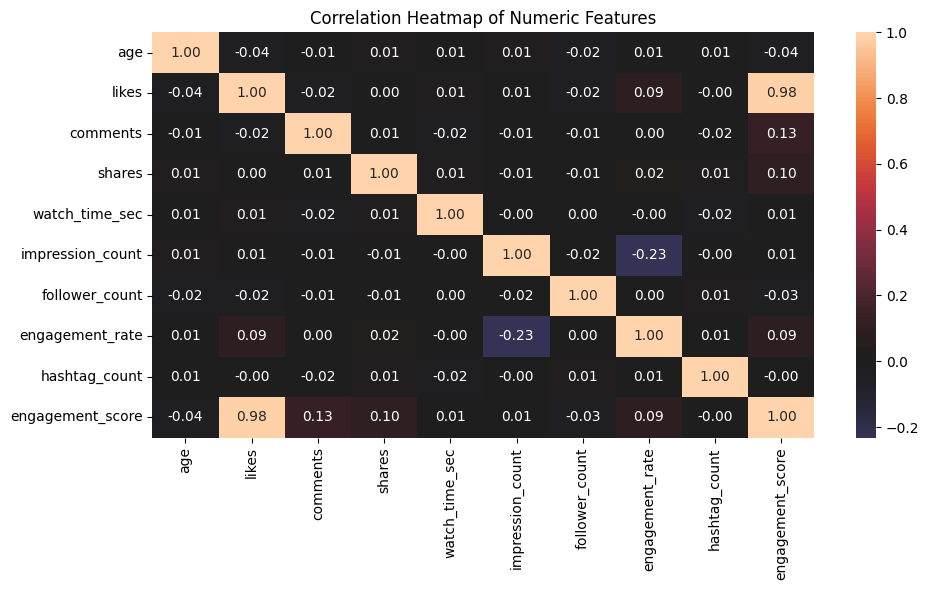

In [ ]:
# 11.Heatmap: Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 45.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 47.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 54.7% of the points cannot be plac

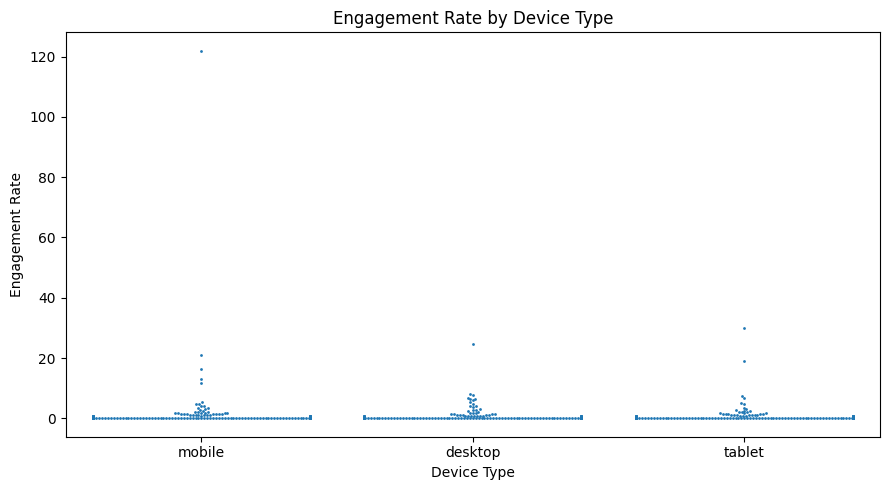

In [ ]:
# 12.Swarm plot: Engagement rate vs device
swarm_sample = df.sample(min(700, len(df)), random_state=42)
plt.figure(figsize=(9,5))
sns.swarmplot(data=swarm_sample, x="device_type", y="engagement_rate", size=2, legend=False)
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.title("Engagement Rate by Device Type")
plt.tight_layout()
plt.show()


8.Interactive Visualization — Plotly

In [66]:
# 13.Interactive line chart
monthly_engagement = (
    df.set_index("posted_at")
      .resample("MS")["engagement_rate"]
      .mean()
      .reset_index())
fig = px.line(
    monthly_engagement,
    x="posted_at",
    y="engagement_rate",
    markers=True,
    title="Interactive Monthly Average Engagement Rate")
fig.update_layout(xaxis_title="Month", yaxis_title="Average Engagement Rate")
fig.show()


In [68]:
# 14. Interactive bubble chart
country_post = df.groupby("country", as_index=False).agg(
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_impressions=("impression_count", "mean"),
    posts=("post_id", "count"))
fig = px.scatter(
    country_post,
    x="avg_impressions",
    y="avg_engagement_rate",
    size="posts",
    hover_name="country",
    title="Country Performance: Impressions vs Engagement Rate",
    labels={
        "avg_impressions": "Average Impressions",
        "avg_engagement_rate": "Average Engagement Rate"})
fig.show()


9.Final Insights & Findings

In [71]:
# Insight extraction
best_post_type = group_post_type.index[0]
best_post_type_rate = group_post_type.iloc[0]["avg_engagement_rate"]
best_category = group_category.index[0]
best_category_rate = group_category.iloc[0]["avg_engagement_rate"]
best_country = country_summary.index[0]
best_country_rate = country_summary.iloc[0]["avg_engagement_rate"]
best_sentiment = group_sentiment.index[0]
best_sentiment_rate = group_sentiment.iloc[0]["avg_engagement_rate"]
verified_rate = df.groupby("is_verified")["engagement_rate"].mean()
device_watch = df.groupby("device_type")["watch_time_sec"].mean().sort_values(ascending=False)
# Age bands for engagement comparison
df["age_group"] = pd.cut(df["age"],
    bins=[12, 17, 24, 34, 44, 54, 64, 100],
    labels=["13-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"])
age_engagement = df.groupby("age_group", observed=False)["engagement_rate"].mean().dropna()
print(f"1. Highest-engagement post type: {best_post_type}")
print(f"2. Best-performing content category: {best_category}")
print(f"3. Country with highest average engagement rate: {best_country}")
print(f"4. Best-performing sentiment by average engagement rate: {best_sentiment}")

1. Highest-engagement post type: image
2. Best-performing content category: education
3. Country with highest average engagement rate: australia
4. Best-performing sentiment by average engagement rate: negative
